# M3 — Data Augmentation & Class Balancing
**DR-Triage · Diabetic Retinopathy Stage Detection**

Covers rubric item 3 (*Data Augmentation & Dataset Balancing*). All logic lives in
`src/augment.py`, driven by the `augment:` block of `config.yaml`.

Two separate problems:
1. **Diversity** — 2.5k training images, one camera type → label-preserving,
   fundus-safe augmentations (with an explicit list of what is *excluded* and why).
2. **Imbalance** — ~9.4 : 1 (No-DR vs Severe) → three strategies compared:
   cost-sensitive **loss weights**, a **weighted sampler**, and **targeted
   oversampling**. Plus **MixUp / CutMix** regularisers.

Figures are saved to `outputs/figures/`.

In [1]:
# --- Setup ---------------------------------------------------------------------
import sys, os, glob, shutil
from pathlib import Path

PROJECT = None
for cand in ["dr-triage", ".", "..", "/kaggle/working/dr-triage"]:
    if (Path(cand) / "src" / "data.py").is_file():
        PROJECT = str(Path(cand).resolve()); break
if PROJECT is None:
    hits = glob.glob("/kaggle/input/**/src/data.py", recursive=True)
    if hits:
        src_root = str(Path(hits[0]).parents[1]); PROJECT = "/kaggle/working/dr-triage"
        shutil.copytree(src_root, PROJECT, dirs_exist_ok=True)
assert PROJECT, "Upload dr-triage.zip via Add Input -> Upload, then re-run."
os.chdir(PROJECT); sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import cv2

from src.data import load_config, load_splits, load_labels, class_weights
from src.preprocess import make_preprocessor
from src.augment import (build_train_aug, build_eval_aug, build_tta_augs,
                         per_class_weights, make_weighted_sampler,
                         oversample_minorities, mixup_batch, cutmix_batch)

cfg = load_config()
FIG = Path(cfg["paths"]["figures_dir"]); FIG.mkdir(parents=True, exist_ok=True)
pre = make_preprocessor(cfg)
MEAN, STD = cfg["image"]["mean"], cfg["image"]["std"]

def read_rgb(p):
    im = cv2.imread(str(p)); return None if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

try:
    train = load_splits(cfg)["train"]
except FileNotFoundError:
    train = load_labels(cfg)
print("train images:", len(train), "| augment config:", cfg["augment"])

/Users/ilmeedesilva/Computer Vision/dr-triage/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train images: 2562 | augment config: {'strength': 1.0, 'balancing': 'oversample', 'oversample_target': 'median', 'oversample_cap_ratio': 4.0, 'class_weight_beta': 0.9999}


## 3.1  The imbalance we are correcting

 stage             name  count  pct
     0            No DR   1263 49.3
     1             Mild    258 10.1
     2         Moderate    699 27.3
     3           Severe    135  5.3
     4 Proliferative DR    207  8.1

imbalance ratio      : 9.4 : 1
minority (Mild/Severe/Proliferative) share : 23.4%


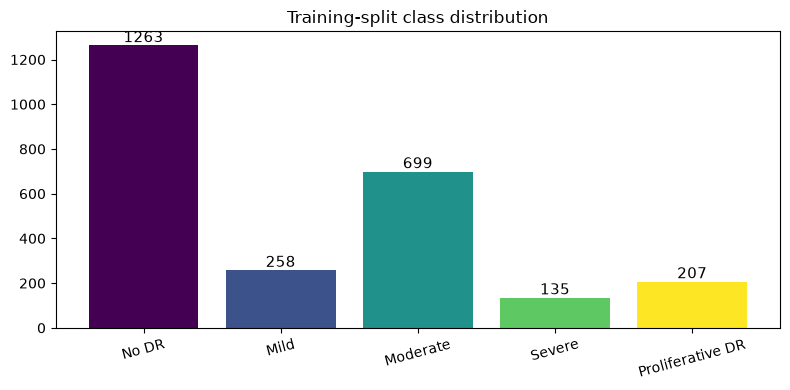

In [2]:
counts = train["stage"].value_counts().sort_index()
names = [cfg["classes"][s] for s in counts.index]
ratio = counts.max() / counts.min()
minority = counts[[1, 3, 4]].sum() / counts.sum() * 100
print(pd.DataFrame({"stage": counts.index, "name": names, "count": counts.values,
                    "pct": (counts.values / counts.sum() * 100).round(1)}).to_string(index=False))
print(f"\nimbalance ratio      : {ratio:.1f} : 1")
print(f"minority (Mild/Severe/Proliferative) share : {minority:.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(names, counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(counts))))
for i, c in enumerate(counts.values):
    ax.text(i, c + 15, str(c), ha="center", fontsize=11)
ax.set_title("Training-split class distribution"); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig(FIG / "03_imbalance.png", dpi=150); plt.show()

## 3.2  Augmentation design — what we apply, and what we deliberately don't

| Applied | p | Why it keeps the DR grade valid |
|---|---|---|
| Horizontal / vertical flip, 90 deg rotate | 0.5 each | the retina has no canonical orientation |
| Affine: <=25 deg rotate, <=10% scale/translate | 0.7 | patient head tilt & camera framing |
| One of Elastic / Grid / Optical distortion (mild) | 0.3 | lens curvature & eye-shape variation |
| Brightness / contrast +/-10% | 0.5 | exposure differences between clinics |
| CoarseDropout (1-8 small holes) | 0.3 | occlusion robustness (lashes, dust, glare) |

**Excluded on purpose** — large hue/saturation shifts & channel shuffle (colour *is*
signal: exudates are yellow, haemorrhages red), heavy blur / downscale (erases
microaneurysms — the earliest DR sign), aggressive crops (can remove the macula or
optic disc and change the correct grade).

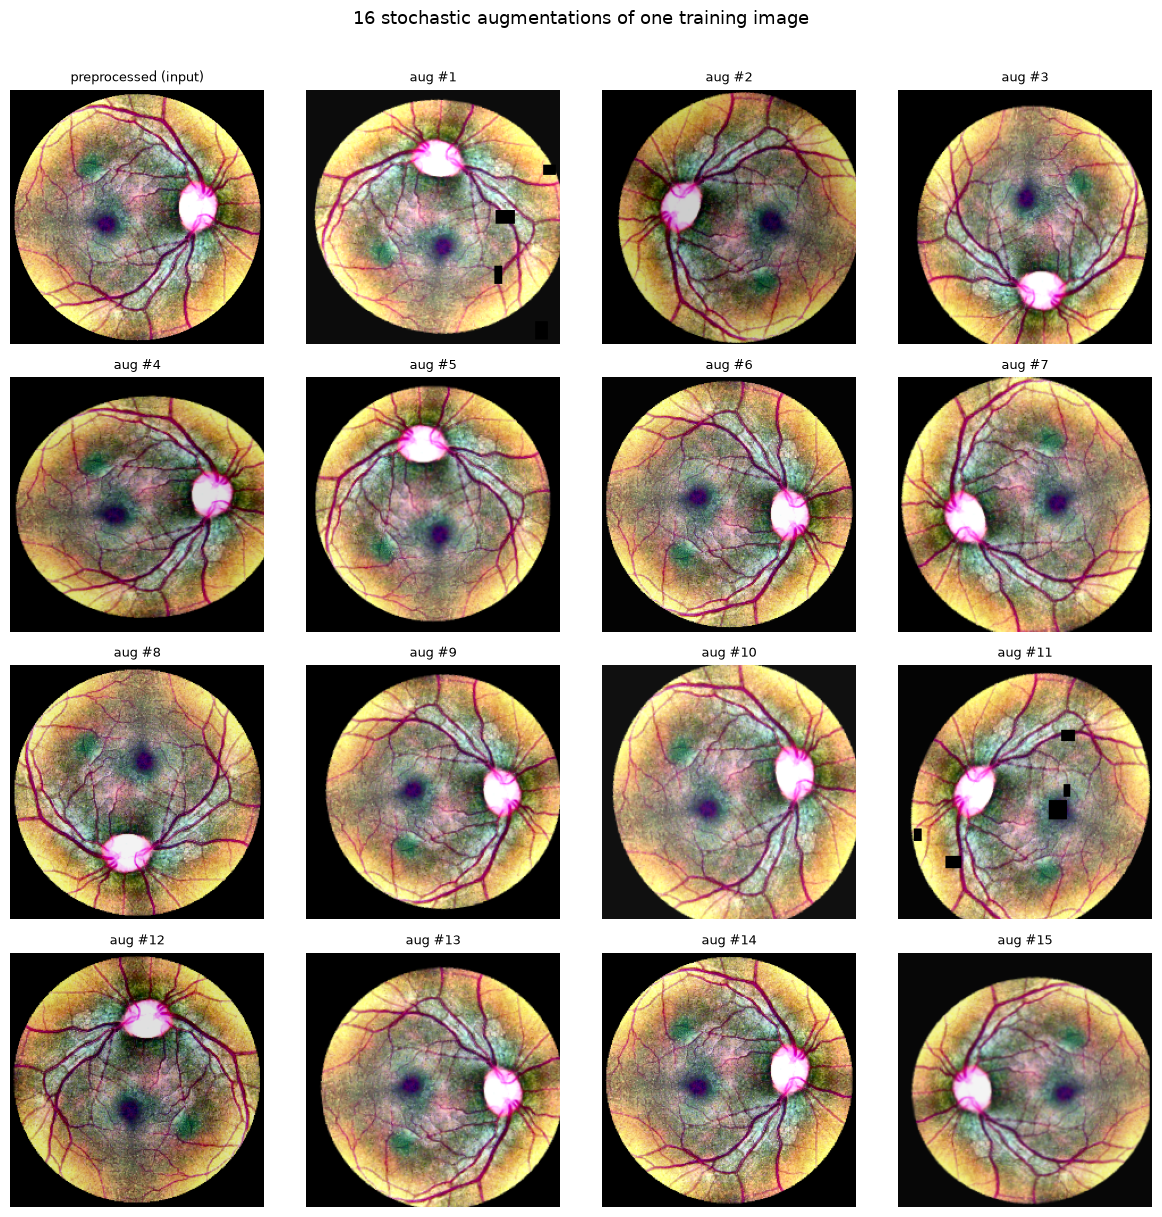

In [3]:
# Visual pipeline (no normalisation) so we can look at it.
viz_aug = build_train_aug(cfg["image"]["size_stage1"], MEAN, STD, strength=1.0, normalize=False)

base = pre(read_rgb(train.iloc[10]["path"]))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(base if k == 0 else viz_aug(image=base)["image"])
    ax.set_title("preprocessed (input)" if k == 0 else f"aug #{k}", fontsize=9)
    ax.axis("off")
fig.suptitle("16 stochastic augmentations of one training image", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(FIG / "03_aug_grid.png", dpi=150, bbox_inches="tight"); plt.show()

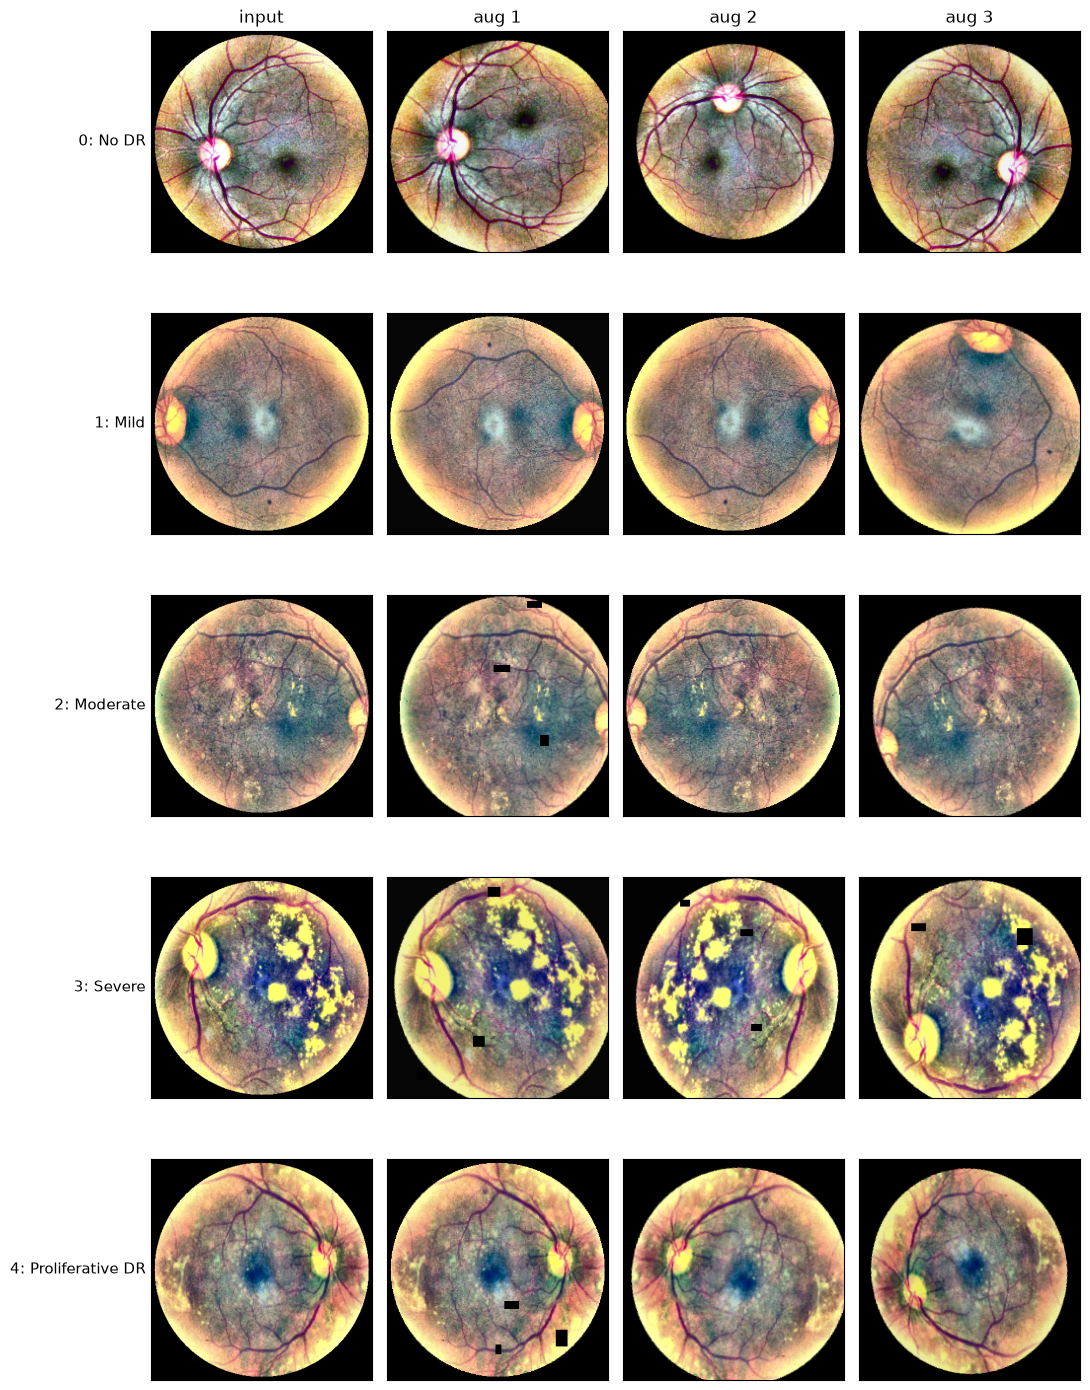

In [4]:
# One row per stage: preprocessed input + 3 augmentations
per_stage = train.sort_values("id_code").groupby("stage", group_keys=False).head(1).sort_values("stage")
rows = len(per_stage)
fig, axes = plt.subplots(rows, 4, figsize=(11, 2.9 * rows))
for r, (_, row) in enumerate(per_stage.iterrows()):
    b = pre(read_rgb(row["path"]))
    axes[r, 0].imshow(b); axes[r, 0].set_ylabel(f'{row["stage"]}: {row["stage_name"]}',
                                                rotation=0, ha="right", va="center", fontsize=11)
    for c in range(1, 4):
        axes[r, c].imshow(viz_aug(image=b)["image"])
    for c in range(4):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_title("input"); [axes[0, c].set_title(f"aug {c}") for c in range(1, 4)]
plt.tight_layout(); plt.savefig(FIG / "03_aug_by_stage.png", dpi=150, bbox_inches="tight"); plt.show()

## 3.3  Class-balancing strategies (compared)

* **A. Loss weights** — cheap, no data change. Plain inverse-frequency vs the
  *effective number of samples* scheme (Cui et al. 2019), which is gentler on the
  tiniest class.
* **B. Weighted sampler** — draw minority rows more often so each *batch* is
  ~balanced; total images seen per epoch unchanged.
* **C. Targeted oversampling** — physically duplicate minority rows up to the
  median count (capped at 4x the smallest class to avoid extreme repetition).

A. per-class loss weights (mean-normalised to 1.0)
 stage             name  inverse_freq  effective_num
     0            No DR         0.216          0.227
     1             Mild         1.057          1.056
     2         Moderate         0.390          0.398
     3           Severe         2.020          2.006
     4 Proliferative DR         1.317          1.313

                   original  weighted_sampler_1epoch  oversampled
No DR                 1263                      499         1263
Mild                   258                      536          258
Moderate               699                      523          699
Severe                 135                      481          258
Proliferative DR       207                      523          258


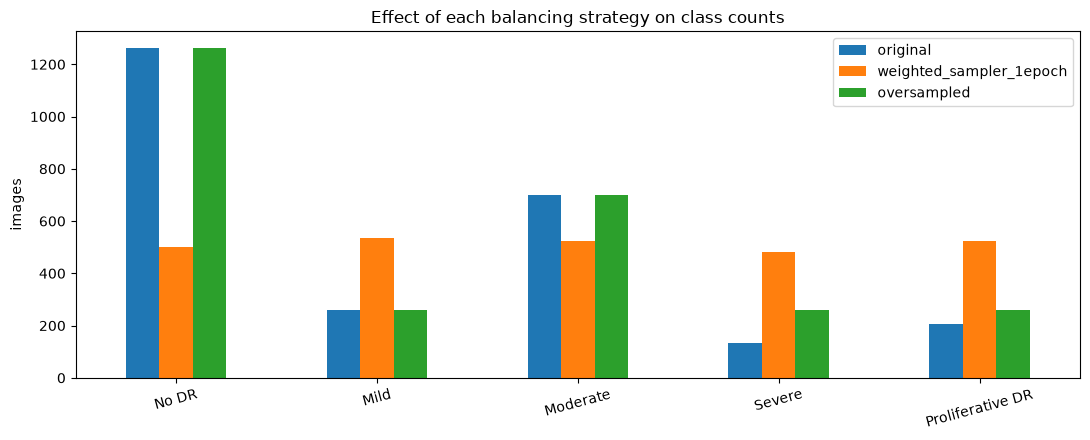

In [5]:
# A. loss weights
w_inv = class_weights(train, 5)
w_eff = per_class_weights(train, 5, beta=cfg["augment"]["class_weight_beta"])
print("A. per-class loss weights (mean-normalised to 1.0)")
print(pd.DataFrame({"stage": range(5), "name": [cfg["classes"][s] for s in range(5)],
                    "inverse_freq": w_inv.round(3), "effective_num": w_eff.round(3)}).to_string(index=False))

# B. weighted sampler — simulate one epoch of draws
sampler = make_weighted_sampler(train, 5)
drawn = train.iloc[list(sampler)]["stage"].value_counts().sort_index()

# C. targeted oversampling
os_df = oversample_minorities(train, target=cfg["augment"]["oversample_target"],
                              cap_ratio=cfg["augment"]["oversample_cap_ratio"], seed=cfg["seed"])
os_counts = os_df["stage"].value_counts().sort_index()

comp = pd.DataFrame({"original": counts, "weighted_sampler_1epoch": drawn,
                     "oversampled": os_counts}).fillna(0).astype(int)
comp.index = [cfg["classes"][s] for s in comp.index]
print("\n", comp.to_string())

ax = comp.plot(kind="bar", figsize=(11, 4.5))
ax.set_ylabel("images"); ax.set_title("Effect of each balancing strategy on class counts")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(FIG / "03_balancing.png", dpi=150); plt.show()

## 3.4  MixUp & CutMix

Batch-level regularisers used during training (M5). **MixUp** = convex blend of two
images; **CutMix** = paste a rectangular patch from another image. Both force the
network to spread evidence across the whole retina instead of memorising one region,
and their soft/partial labels (via `lam`) pair naturally with the ordinal head.

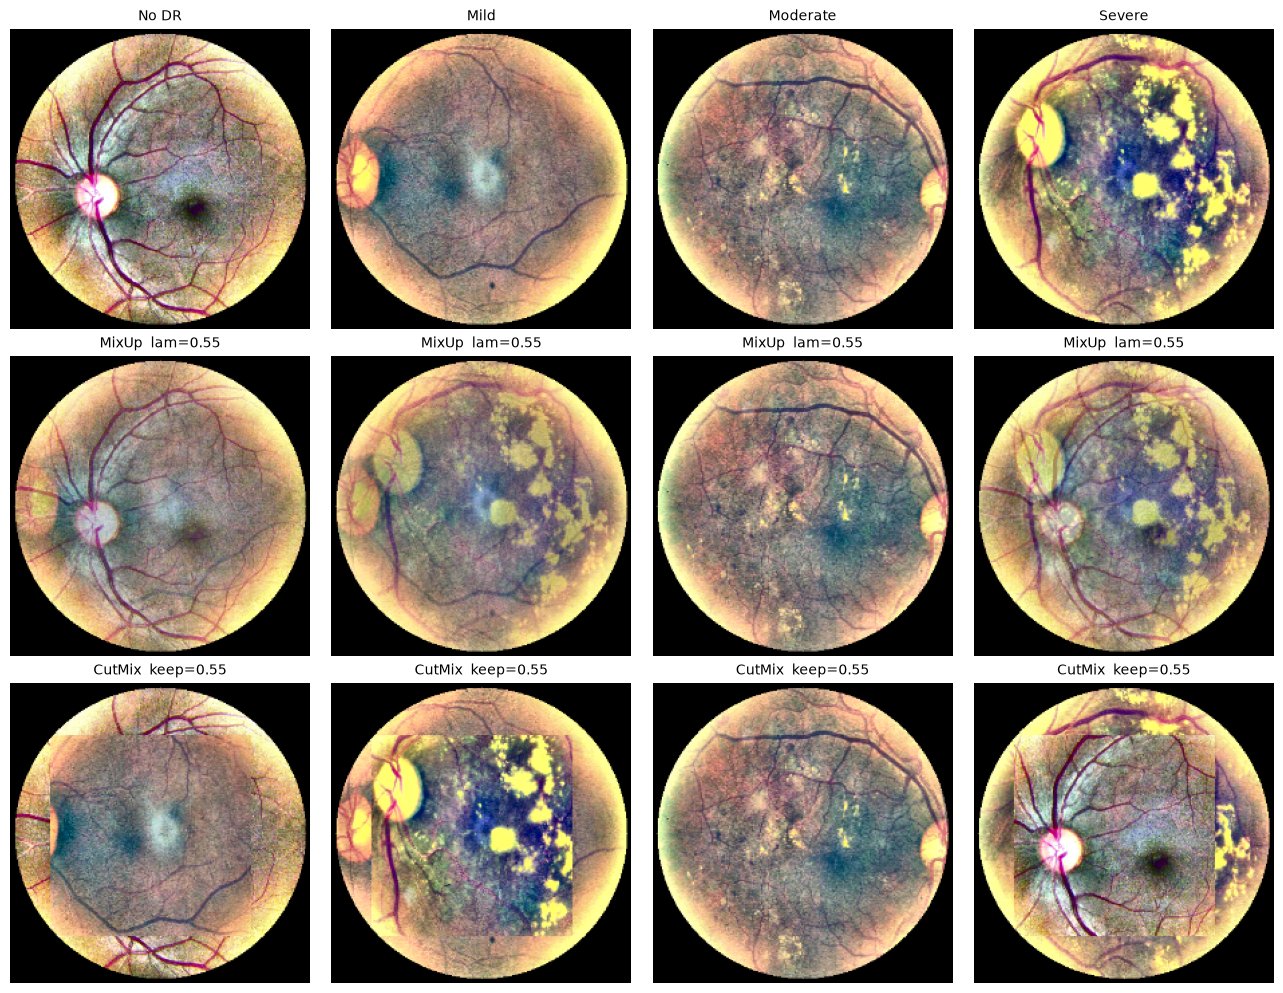

In [6]:
size = cfg["image"]["size_stage1"]
def load01(p):
    im = cv2.resize(pre(read_rgb(p)), (size, size))
    return torch.from_numpy(im).permute(2, 0, 1).float() / 255.0

batch = torch.stack([load01(p) for p in per_stage["path"].tolist()[:4]])
mx, _, lm = mixup_batch(batch,  cfg["train"]["mixup_alpha"],  seed=1, lam=0.55)   # lam forced for a clear picture
cx, _, lc = cutmix_batch(batch, cfg["train"]["cutmix_alpha"], seed=1, lam=0.55)
show = lambda t: t.permute(1, 2, 0).clamp(0, 1).numpy()

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for j in range(4):
    axes[0, j].imshow(show(batch[j])); axes[0, j].set_title(per_stage.iloc[j]["stage_name"], fontsize=10)
    axes[1, j].imshow(show(mx[j]));    axes[1, j].set_title(f"MixUp  lam={lm:.2f}", fontsize=10)
    axes[2, j].imshow(show(cx[j]));    axes[2, j].set_title(f"CutMix  keep={lc:.2f}", fontsize=10)
for ax in axes.ravel(): ax.axis("off")
axes[0, 0].set_ylabel("original", rotation=0, ha="right", va="center")
plt.tight_layout(); plt.savefig(FIG / "03_mixup_cutmix.png", dpi=150, bbox_inches="tight"); plt.show()

## 3.5  Decision & leakage note  *(report-ready)*

**What training (M5) will use:**
* Augmentation: the fundus-safe pipeline above, `strength = 1.0`, applied on the
  fly to the **training split only**.
* Balancing: **targeted oversampling to the median** (`augment.balancing:
  oversample`) *and* the **effective-number loss weights** as a light second
  correction. The weighted sampler is kept available for an ablation.
* **MixUp / CutMix**: applied per-batch with probability 0.5 (one or the other),
  `alpha` = 0.2 / 1.0.

**Why this combination:** oversampling to the *median* (not the max) plus a capped
duplication ratio rebalances the rare Severe / Proliferative classes without
turning the epoch into 60% duplicated images; the mild loss weights then nudge the
remaining gap. MixUp/CutMix counteract the overfitting risk that oversampling adds.

**No leakage:** every augmentation, the sampler, and the oversampling act on the
**training split only**. Validation and test use `build_eval_aug` (resize + normalise).
Test-time augmentation for inference (`build_tta_augs`: identity / H-flip / V-flip /
180 deg) is deterministic and label-preserving.

## Milestone status
- [x] M1 — EDA + stratified split
- [x] M2 — preprocessing pipeline
- [x] **M3 — augmentation + class balancing** (`src/augment.py`), figures in `outputs/figures/`
- [ ] M4 — EfficientNetV2 + CBAM + stage/ordinal/referable heads → `notebooks/04_train.ipynb`